# Day 24: GPR 核函数对比
RBF vs Matern vs RationalQuadratic — 哪个核函数最好？

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF, Matern, RationalQuadratic,
    ConstantKernel as C, WhiteKernel
)
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib
import json
import time
import warnings
import os
os.chdir('D:/MY_Learning/matbench-dielectric/notebooks')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')

# 加载数据
df = pd.read_csv('../data/dielectric_cleaned.csv')
X = df.drop('n_dielectric', axis=1)
y = np.log1p(df['n_dielectric'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 子采样
N_SUBSAMPLE = 1500
np.random.seed(42)
idx = np.random.choice(len(X_train_scaled), N_SUBSAMPLE, replace=False)
X_tr = X_train_scaled[idx]
y_tr = y_train.iloc[idx].values

print("数据准备完成")
print(f"GPR 训练数据: {X_tr.shape[0]} 样本 x {X_tr.shape[1]} 特征")

数据准备完成
GPR 训练数据: 1500 样本 x 135 特征


## 4 种核函数
核函数 = GPR 对"两个样本有多像"的定义。不同的核适合不同的数据类型。

In [8]:
print("=" * 60)
print("训练 4 种核函数")
print("=" * 60)

# 只保留有代表性的 4 种
kernels = {
    'RBF+噪声': C(1.0) * RBF(1.0) + WhiteKernel(1.0),
    'Matern nu=0.5': C(1.0) * Matern(nu=0.5, length_scale=1.0) + WhiteKernel(1.0),
    'Matern nu=1.5': C(1.0) * Matern(nu=1.5, length_scale=1.0) + WhiteKernel(1.0),
    'RationalQuadratic': C(1.0) * RationalQuadratic(alpha=1.0, length_scale=1.0) + WhiteKernel(1.0)
}

print(f"\nRBF: 最平滑，假设数据无限可导")
print(f"Matern nu=0.5: 最粗糙，连续但不可导")
print(f"Matern nu=1.5: 中等，一阶可导（最常用）")
print(f"RationalQuadratic: 多尺度混合，捕捉长短期相关性")

results = []
for name, kernel in kernels.items():
    print(f"\n训练 {name}...")
    gpr = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=10,
        alpha=1e-6,
        normalize_y=True,
        random_state=42
    )
    start = time.time()
    gpr.fit(X_tr, y_tr)
    elapsed = time.time() - start

    y_pred, y_std = gpr.predict(X_test_scaled, return_std=True)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    errors = np.abs(y_test - y_pred)
    corr = np.corrcoef(y_std, errors)[0, 1]

    results.append({
        'kernel': name,
        'r2': r2, 'rmse': rmse,
        'mean_std': y_std.mean(),
        'corr': corr,
        'log_lik': gpr.log_marginal_likelihood_value_,
        'time': elapsed,
        'optimized_kernel': str(gpr.kernel_),
        'model': gpr,
        'y_pred': y_pred, 'y_std': y_std
    })
    print(f"  R²={r2:.4f}, RMSE={rmse:.4f}, 耗时={elapsed:.0f}s, corr={corr:.3f}")

# 转 DataFrame + 找最佳
comparison_df = pd.DataFrame(results)
best_idx = comparison_df['r2'].idxmax()
best_kernel = comparison_df.loc[best_idx, 'kernel']
best_r2 = comparison_df.loc[best_idx, 'r2']
best_result = results[best_idx]

print(f"\n最佳核函数: {best_kernel} (R²={best_r2:.4f})")
print(f"其他核函数 R² 差距: {(comparison_df['r2'].max() - comparison_df['r2'].min()):.4f}")

训练 4 种核函数

RBF: 最平滑，假设数据无限可导
Matern nu=0.5: 最粗糙，连续但不可导
Matern nu=1.5: 中等，一阶可导（最常用）
RationalQuadratic: 多尺度混合，捕捉长短期相关性

训练 RBF+噪声...
  R²=0.6599, RMSE=0.1520, 耗时=91s, corr=0.294

训练 Matern nu=0.5...
  R²=0.6659, RMSE=0.1506, 耗时=112s, corr=0.280

训练 Matern nu=1.5...
  R²=0.6615, RMSE=0.1516, 耗时=122s, corr=0.304

训练 RationalQuadratic...
  R²=0.6599, RMSE=0.1520, 耗时=192s, corr=0.294

最佳核函数: Matern nu=0.5 (R²=0.6659)
其他核函数 R² 差距: 0.0061


## 核函数对比（6 维度）

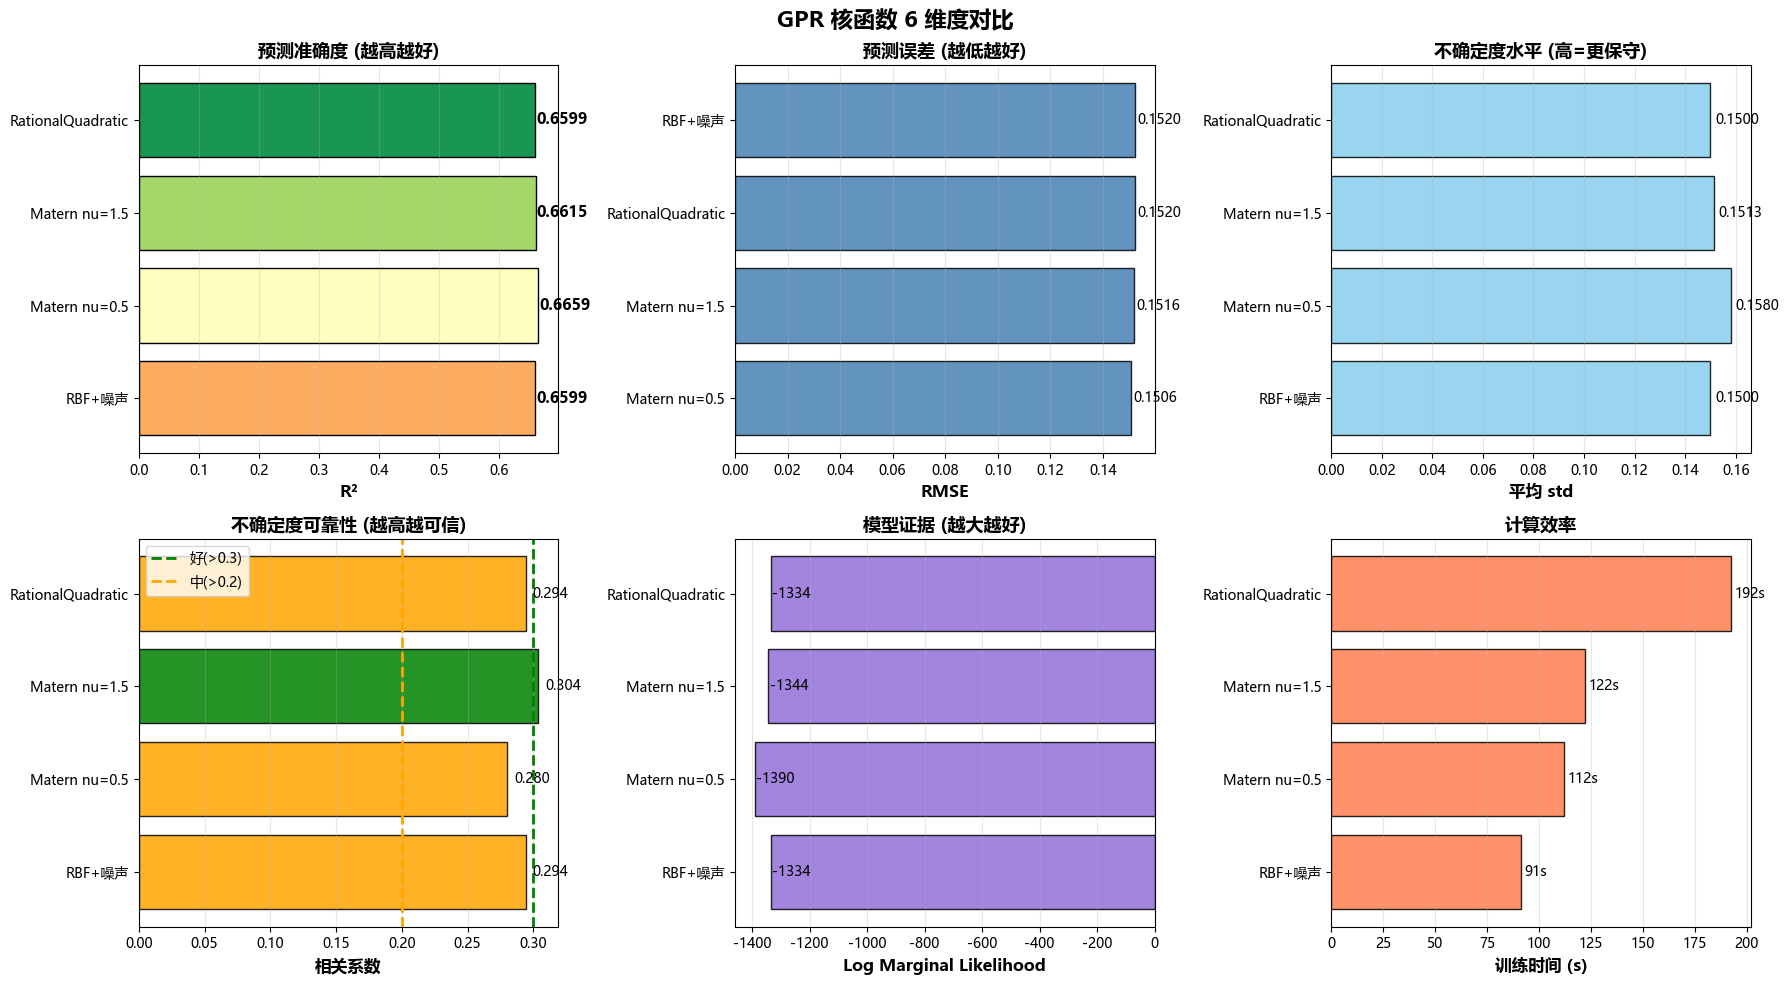

✓ 对比图已保存


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. R²
ax = axes[0, 0]
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(comparison_df)))
bars = ax.barh(comparison_df['kernel'], comparison_df['r2'], color=colors, edgecolor='black')
ax.set_xlabel('R²', fontsize=12, fontweight='bold')
ax.set_title('预测准确度 (越高越好)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, comparison_df['r2']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=11, fontweight='bold')

# 2. RMSE
ax = axes[0, 1]
df_sorted = comparison_df.sort_values('rmse', ascending=True)
bars = ax.barh(df_sorted['kernel'], df_sorted['rmse'], color='steelblue', alpha=0.85, edgecolor='black')
ax.set_xlabel('RMSE', fontsize=12, fontweight='bold')
ax.set_title('预测误差 (越低越好)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, df_sorted['rmse']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)

# 3. 不确定度水平
ax = axes[0, 2]
bars = ax.barh(comparison_df['kernel'], comparison_df['mean_std'],
               color='skyblue', alpha=0.85, edgecolor='black')
ax.set_xlabel('平均 std', fontsize=12, fontweight='bold')
ax.set_title('不确定度水平 (高=更保守)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, comparison_df['mean_std']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)

# 4. 不确定度可靠性
ax = axes[1, 0]
gap_colors = ['green' if c > 0.3 else 'orange' if c > 0.2 else 'red' for c in comparison_df['corr']]
bars = ax.barh(comparison_df['kernel'], comparison_df['corr'],
               color=gap_colors, alpha=0.85, edgecolor='black')
ax.axvline(0.3, color='green', linestyle='--', linewidth=2, label='好(>0.3)')
ax.axvline(0.2, color='orange', linestyle='--', linewidth=2, label='中(>0.2)')
ax.set_xlabel('相关系数', fontsize=12, fontweight='bold')
ax.set_title('不确定度可靠性 (越高越可信)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, comparison_df['corr']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

# 5. 对数边际似然
ax = axes[1, 1]
bars = ax.barh(comparison_df['kernel'], comparison_df['log_lik'],
               color='mediumpurple', alpha=0.85, edgecolor='black')
ax.set_xlabel('Log Marginal Likelihood', fontsize=12, fontweight='bold')
ax.set_title('模型证据 (越大越好)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, comparison_df['log_lik']):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=10)

# 6. 训练时间
ax = axes[1, 2]
df_time = comparison_df.sort_values('time', ascending=True)
bars = ax.barh(df_time['kernel'], df_time['time'],
               color='coral', alpha=0.85, edgecolor='black')
ax.set_xlabel('训练时间 (s)', fontsize=12, fontweight='bold')
ax.set_title('计算效率', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, df_time['time']):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}s', va='center', fontsize=10)

plt.suptitle('GPR 核函数 6 维度对比', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/day24_kernel_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ 对比图已保存")

## 最佳核函数详细分析

最佳核函数: Matern nu=0.5
优化后参数: 4.68**2 * Matern(length_scale=619, nu=0.5) + WhiteKernel(noise_level=0.176)


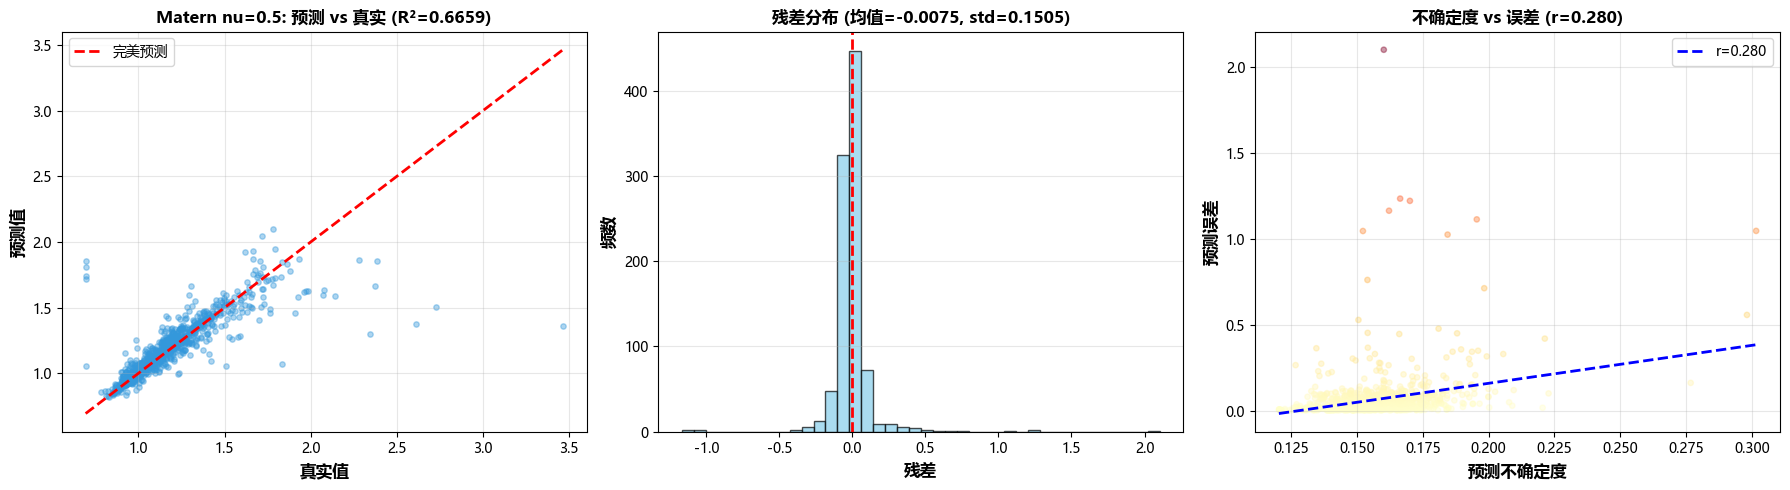

✓ 最佳核函数分析图已保存


In [16]:
print(f"最佳核函数: {best_kernel}")
print(f"优化后参数: {best_result['optimized_kernel']}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 子图 1：预测 vs 真实
ax = axes[0]
ax.scatter(y_test, best_result['y_pred'], alpha=0.4, s=15, color='#3498db')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
        'r--', lw=2, label='完美预测')
ax.set_xlabel('真实值', fontsize=12, fontweight='bold')
ax.set_ylabel('预测值', fontsize=12, fontweight='bold')
ax.set_title(f'{best_kernel}: 预测 vs 真实 (R²={best_result["r2"]:.4f})',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 子图 2：残差分布
ax = axes[1]
residuals = y_test - best_result['y_pred']
ax.hist(residuals, bins=40, alpha=0.7, color='skyblue', edgecolor='black')
ax.axvline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('残差', fontsize=12, fontweight='bold')
ax.set_ylabel('频数', fontsize=12, fontweight='bold')
ax.set_title(f'残差分布 (均值={residuals.mean():.4f}, std={residuals.std():.4f})',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 子图 3：不确定度 vs 误差
ax = axes[2]
errors = np.abs(residuals)
ax.scatter(best_result['y_std'], errors, alpha=0.4, s=15, c=errors, cmap='YlOrRd')
z = np.polyfit(best_result['y_std'], errors, 1)
x_line = np.linspace(best_result['y_std'].min(), best_result['y_std'].max(), 50)
ax.plot(x_line, np.polyval(z, x_line), 'b--', linewidth=2, label=f'r={best_result["corr"]:.3f}')
ax.set_xlabel('预测不确定度', fontsize=12, fontweight='bold')
ax.set_ylabel('预测误差', fontsize=12, fontweight='bold')
ax.set_title(f'不确定度 vs 误差 (r={best_result["corr"]:.3f})', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/day24_best_kernel_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 最佳核函数分析图已保存")

## 保存 + 总结

In [17]:
# 保存最佳模型
joblib.dump(best_result['model'], '../models/day24_gpr_best_kernel.pkl')
print(f"✓ 最佳模型已保存: {best_kernel}")

# 保存对比结果
def to_python(obj):
    if isinstance(obj, (np.integer,)): return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, np.ndarray): return obj.tolist()
    if isinstance(obj, dict): return {k: to_python(v) for k, v in obj.items()}
    if isinstance(obj, list): return [to_python(v) for v in obj]
    return obj

with open('../models/day24_kernel_comparison.json', 'w') as f:
    json.dump({
        'best_kernel': best_kernel,
        'best_r2': float(best_r2),
        'results': to_python([{
            'kernel': r['kernel'],
            'r2': r['r2'], 'rmse': r['rmse'],
            'corr': r['corr'], 'time': r['time']
        } for r in results]),
    }, f, indent=2)
print("✓ 结果已保存")

# 加载之前的模型做最终对比
print("\n" + "=" * 60)
print("Day 24 总结")
print("=" * 60)

print(f"\n4 种核函数对比:")
for r in results:
    mark = " ← 最佳" if r['kernel'] == best_kernel else ""
    print(f"  {r['kernel']:25s} R²={r['r2']:.4f}  corr={r['corr']:.3f}  {r['time']:.0f}s{mark}")

r2_range = comparison_df['r2'].max() - comparison_df['r2'].min()
print(f"\n关键发现:")
print(f"  核函数之间 R² 差异: {r2_range:.4f} (非常小)")
if r2_range < 0.01:
    print(f"  → 结论: 核函数选择对这个数据集影响不大")
    print(f"  → 原因: 1500 样本在 135 维空间中太稀疏, 核函数的形态差异被覆盖")
    print(f"  → 建议: 直接用 RBF+噪声, 不用花时间试别的核")
print(f"\n  不确定度可靠性: 所有核函数的 corr 都 < 0.30")
print(f"  → 高维场景下不确定度的可靠性有限, 这是 GPR 的已知局限")
print("=" * 60)

✓ 最佳模型已保存: Matern nu=0.5
✓ 结果已保存

Day 24 总结

4 种核函数对比:
  RBF+噪声                    R²=0.6599  corr=0.294  91s
  Matern nu=0.5             R²=0.6659  corr=0.280  112s ← 最佳
  Matern nu=1.5             R²=0.6615  corr=0.304  122s
  RationalQuadratic         R²=0.6599  corr=0.294  192s

关键发现:
  核函数之间 R² 差异: 0.0061 (非常小)
  → 结论: 核函数选择对这个数据集影响不大
  → 原因: 1500 样本在 135 维空间中太稀疏, 核函数的形态差异被覆盖
  → 建议: 直接用 RBF+噪声, 不用花时间试别的核

  不确定度可靠性: 所有核函数的 corr 都 < 0.30
  → 高维场景下不确定度的可靠性有限, 这是 GPR 的已知局限


4 种 GPR 核函数（RBF、Matérn ν=0.5/1.5、RationalQuadratic），R² 差异 < 0.01。结论：核函数选择对这个高维数据集影响不大，直接用 RBF+噪声即可。